# 7. Risk Attribution

This notebook decomposes portfolio market risk into asset-level contributions.

The analysis covers:

1. Portfolio Risk Measurement
2. Portfolio Parametric VaR
3. Marginal VaR
4. Component VaR
5. Percentage Contribution to VaR
6. Euler Decomposition Validation

The portfolio consists of SPY, QQQ, IWM, TLT, and GLD with fixed portfolio weights.

The objective is to identify how individual assets contribute to total portfolio VaR and to validate the risk decomposition using Euler's theorem.

In [45]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from project_01_market_risk_engine.src.data import download_prices
from project_01_market_risk_engine.src.var import parametric_var
from project_01_market_risk_engine.src.risk_attribution import marginal_var, component_var, var_contribution

In [46]:
TICKERS = [
    "SPY",
    "QQQ",
    "IWM",
    "TLT",
    "GLD"
]

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

weights = pd.Series({
    "SPY": 0.30,
    "QQQ": 0.20,
    "IWM": 0.15,
    "TLT": 0.20,
    "GLD": 0.15
})

In [47]:
prices = download_prices(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE
)

returns = prices.pct_change().dropna()

[*********************100%***********************]  5 of 5 completed


## 1. Portfolio Risk Measurement

Portfolio returns are calculated as the weighted sum of individual asset returns.

Portfolio volatility is derived from the covariance matrix:

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

where **w** represents the portfolio weights and **Σ** represents the covariance matrix of asset returns.

In [48]:
portfolio_returns = returns @ weights
portfolio_mean_return = portfolio_returns.mean()
portfolio_mean_return

np.float64(0.00046314846654835353)

In [49]:
covariance_matrix = returns.cov()
portfolio_variance = weights.T @ covariance_matrix @ weights
portfolio_volatility = np.sqrt(portfolio_variance)
portfolio_volatility

np.float64(0.008089912644984924)

## 2. Portfolio Parametric VaR

Parametric VaR estimates portfolio losses using the portfolio return distribution and an assumed normal distribution.

VaR is calculated at the 95% and 99% confidence levels to assess portfolio losses under different tail thresholds.

In [50]:

confidence_levels = [0.95, 0.99]
portfolio_var = {}

for level in confidence_levels:
    portfolio_var[level] = parametric_var(
        returns=portfolio_returns,
        confidence_level=level
    )
portfolio_var
    

{0.95: np.float64(0.012843573689275677),
 0.99: np.float64(0.018356802616288442)}

## 3. Marginal VaR

Marginal VaR measures the sensitivity of portfolio VaR to a small change in the portfolio weight of an individual asset.

The marginal volatility contribution of asset *i* is calculated as:

$$
\frac{\partial \sigma_p}{\partial w_i} = \frac{(\Sigma w)_i}{\sigma_p}
$$

The resulting sensitivity is then used to calculate Marginal VaR for each asset.

A positive Marginal VaR indicates that increasing the asset's portfolio weight would increase portfolio VaR, while a negative value indicates a potential diversification benefit.

In [51]:
mvar = {}

for level in confidence_levels:
    mvar[level] = marginal_var(
        covariance_matrix=covariance_matrix,
        weights=weights,
        portfolio_volatility=portfolio_volatility,
        portfolio_mean_return=portfolio_mean_return,
        confidence_level=level
    )
    
mvar

{0.95: Ticker
 GLD    0.003916
 IWM    0.019540
 QQQ    0.020290
 SPY    0.016642
 TLT    0.001373
 dtype: float64,
 0.99: Ticker
 GLD    0.005730
 IWM    0.027828
 QQQ    0.028888
 SPY    0.023730
 TLT    0.002133
 dtype: float64}

### Marginal VaR by Asset

The table below shows the Marginal VaR associated with each asset at the 95% and 99% confidence levels.

In [52]:
mvar_df = pd.DataFrame({
    "Weight": weights,
    **{f"MVaR {int(level*100)}%": series for level, series in mvar.items()}
})

mvar_df

,Weight,MVaR 95%,MVaR 99%
GLD,0.15,0.003916,0.005730
IWM,0.15,0.019540,0.027828
QQQ,0.20,0.020290,0.028888
SPY,0.30,0.016642,0.023730
TLT,0.20,0.001373,0.002133


## 4. Component VaR

Component VaR converts Marginal VaR into the total contribution of each asset to portfolio VaR.

The Component VaR of asset *i* is:

$$
CVaR_i = w_i \times MVaR_i
$$

Under Euler decomposition, the sum of the individual Component VaRs should equal total portfolio VaR.

In [53]:
component_var_values = {}

for level in confidence_levels:
    component_var_values[level] = component_var(
        weights=weights,
        marginal_var_values= mvar[level]
    )
    
component_var_df = pd.DataFrame({
    "Weight": weights,
    **{
        f"Component VaR {int(level*100)}%": series
        for level, series in component_var_values.items()        
    }
})

component_var_df

,Weight,Component VaR 95%,Component VaR 99%
GLD,0.15,0.000587,0.000859
IWM,0.15,0.002931,0.004174
QQQ,0.20,0.004058,0.005778
SPY,0.30,0.004993,0.007119
TLT,0.20,0.000275,0.000427


## 5. Percentage Contribution to VaR

Percentage contribution measures the proportion of total portfolio VaR attributable to each asset.

It is calculated as:

$$
\text{VaR Contribution}_i = \frac{\text{CVaR}_i}{\text{VaR}_p}
$$

The individual contributions should sum to approximately 100%.

In [54]:
percentage_contribution = {}

for level in confidence_levels:
    percentage_contribution[level] = var_contribution(
        component_var_values=component_var_values[level]
    )

contribution_df = pd.DataFrame({
    "Weight": weights,
    **{
        f"Component VaR {int(level*100)}%": component_var_values[level]
        for level in confidence_levels
    },
    **{
        f"VaR Contribution {int(level*100)}%": percentage_contribution[level]
        for level in confidence_levels
    }
})

contribution_df

,Weight,Component VaR 95%,Component VaR 99%,VaR Contribution 95%,VaR Contribution 99%
GLD,0.15,0.000587,0.000859,0.045732,0.046822
IWM,0.15,0.002931,0.004174,0.228211,0.227394
QQQ,0.20,0.004058,0.005778,0.315951,0.314739
SPY,0.30,0.004993,0.007119,0.388732,0.387805
TLT,0.20,0.000275,0.000427,0.021374,0.023241


In [55]:
for level in confidence_levels:
    contribution_total = percentage_contribution[level].sum()

    print(
        f"{int(level * 100)}% VaR contribution total: "
        f"{contribution_total:.2%}"
    )

95% VaR contribution total: 100.00%
99% VaR contribution total: 100.00%


## 6. Euler Decomposition Validation

The Euler decomposition confirms that the sum of the individual Component VaRs reconstructs the total portfolio VaR.

A near-zero difference indicates that the risk attribution is internally consistent with the portfolio VaR calculation.

In [56]:
for level in confidence_levels:
    total_component_var = component_var_values[level].sum()

    print(f"{int(level * 100)}% VaR")
    print(f"Portfolio VaR:        {portfolio_var[level]:.8f}")
    print(f"Component VaR total:  {total_component_var:.8f}")
    print(
        f"Difference:           "
        f"{portfolio_var[level] - total_component_var:.10f}"
    )
    print()

95% VaR
Portfolio VaR:        0.01284357
Component VaR total:  0.01284357
Difference:           0.0000000000

99% VaR
Portfolio VaR:        0.01835680
Component VaR total:  0.01835680
Difference:           0.0000000000



## Risk Attribution Analysis

The final risk attribution combines portfolio weights, Marginal VaR, Component VaR, and percentage VaR contribution to provide an asset-level view of portfolio risk.

In [57]:
risk_attribution_df = pd.DataFrame({
    "Weight": weights,
    "MVaR 95%": mvar[0.95],
    "Component VaR 95%": component_var_values[0.95],
    "VaR Contribution 95%": percentage_contribution[0.95],
    "MVaR 99%": mvar[0.99],
    "Component VaR 99%": component_var_values[0.99],
    "VaR Contribution 99%": percentage_contribution[0.99],
})

risk_attribution_df

,Weight,MVaR 95%,Component VaR 95%,VaR Contribution 95%,MVaR 99%,Component VaR 99%,VaR Contribution 99%
GLD,0.15,0.003916,0.000587,0.045732,0.005730,0.000859,0.046822
IWM,0.15,0.019540,0.002931,0.228211,0.027828,0.004174,0.227394
QQQ,0.20,0.020290,0.004058,0.315951,0.028888,0.005778,0.314739
SPY,0.30,0.016642,0.004993,0.388732,0.023730,0.007119,0.387805
TLT,0.20,0.001373,0.000275,0.021374,0.002133,0.000427,0.023241


### Portfolio Weight vs. VaR Contribution

Comparing portfolio weights with VaR contributions highlights whether an asset contributes proportionally to portfolio risk.

An asset whose VaR contribution exceeds its portfolio weight contributes more risk than its allocation would suggest, while an asset whose VaR contribution is below its portfolio weight provides relative diversification benefits.

### Portfolio Weight vs. VaR Contribution

Comparing portfolio weights with VaR contributions highlights whether an asset contributes proportionally to portfolio risk.

An asset whose VaR contribution exceeds its portfolio weight contributes more risk than its allocation would suggest, while an asset whose VaR contribution is below its portfolio weight provides relative diversification benefits.

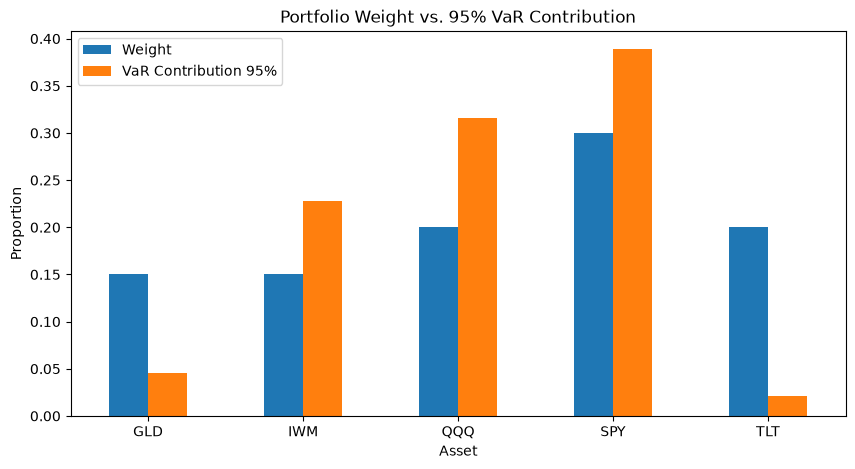

In [58]:
comparison_df = risk_attribution_df[
    ["Weight", "VaR Contribution 95%"]
].copy()

comparison_df.plot(
    kind="bar",
    figsize=(10, 5),
    title="Portfolio Weight vs. 95% VaR Contribution"
)

plt.ylabel("Proportion")
plt.xlabel("Asset")
plt.xticks(rotation=0)
plt.show()

### Component VaR by Asset

Component VaR shows the absolute contribution of each asset to total portfolio VaR.

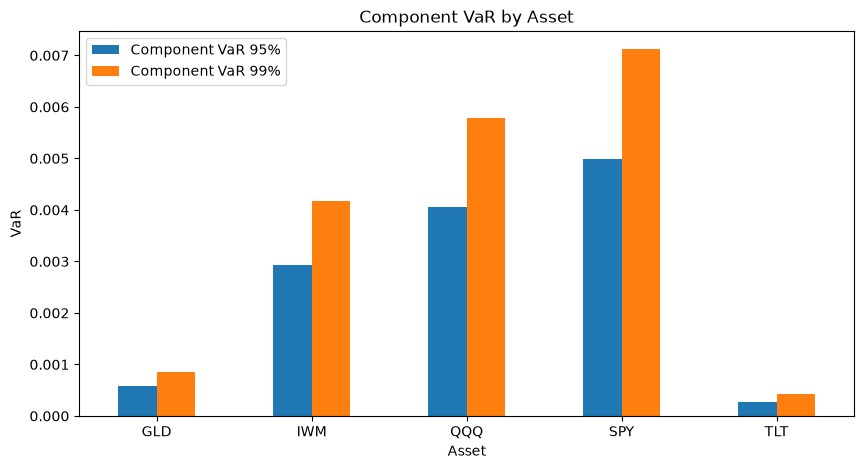

In [59]:
component_var_df[
    ["Component VaR 95%", "Component VaR 99%"]
].plot(
    kind="bar",
    figsize=(10, 5),
    title="Component VaR by Asset"
)

plt.ylabel("VaR")
plt.xlabel("Asset")
plt.xticks(rotation=0)
plt.show()

## Key Observations

The portfolio's risk contribution is not proportional to its portfolio weights.

- **SPY** has the largest portfolio weight and also contributes the largest share of portfolio VaR.
- **QQQ** has a 20% portfolio weight but contributes approximately 31.6% of 95% VaR, indicating a disproportionately large contribution to portfolio risk.
- **IWM** has a 15% portfolio weight but contributes approximately 22.8% of 95% VaR.
- **GLD** and **TLT** contribute substantially less to portfolio VaR relative to their portfolio weights, indicating diversification benefits within the portfolio.
- The Component VaR contributions sum to total portfolio VaR at both the 95% and 99% confidence levels.
- The Euler decomposition therefore provides an internally consistent attribution of portfolio Parametric VaR.